In [1]:

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
print("Seed:", SEED)

Seed: 42


In [4]:
N = 7000
D = 20

X = np.random.normal(size=(N, D)).astype(np.float32)

In [5]:
z = (
    0.85 * X[:, 0]
    - 0.65 * X[:, 1]
    + 0.45 * X[:, 4]
    + 1.10 * X[:, 2] * X[:, 3]
    + 0.95 * np.sin(1.6 * X[:, 5])
    - 0.55 * (X[:, 6] ** 2 - 1)
    - 0.65
)

In [6]:
p = 1 / (1 + np.exp(-z))

y = (
    np.random.rand(N) < p
).astype(np.float32)

In [7]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Positive rate:", y.mean())

X shape: (7000, 20)
y shape: (7000,)
Positive rate: 0.39485714


In [8]:
idx = np.arange(N)
np.random.shuffle(idx)

n_train = int(0.60 * N)
n_val = int(0.20 * N)

train_idx = idx[:n_train]
val_idx = idx[n_train:n_train+n_val]
test_idx = idx[n_train+n_val:]

In [9]:
X_train = X[train_idx]
X_val = X[val_idx]
X_test = X[test_idx]

y_train = y[train_idx]
y_val = y[val_idx]
y_test = y[test_idx]

In [10]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(4200, 20)
(1400, 20)
(1400, 20)


In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [12]:
print(
    X_train.mean(axis=0)[:5]
)

print(
    X_train.std(axis=0)[:5]
)

[-6.0810930e-09 -1.3428785e-09 -1.6916365e-08  5.7688783e-09
  9.4515933e-09]
[0.9999993  0.9999997  0.99999994 1.0000001  1.0000001 ]


In [13]:
N_SMALL = 300

X_train_small = X_train[:N_SMALL]
y_train_small = y_train[:N_SMALL]

print(X_train_small.shape)

(300, 20)


In [14]:
train_small_dataset = TensorDataset(
    torch.tensor(
        X_train_small,
        dtype=torch.float32
    ),
    torch.tensor(
        y_train_small,
        dtype=torch.float32
    )
)

train_small_loader = DataLoader(
    train_small_dataset,
    batch_size=32,
    shuffle=True
)

In [15]:
class OverfitNet(nn.Module):

    def __init__(self, n_features):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(n_features, 256),
            nn.ReLU(),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 1)
        )

    def forward(self, x):

        return self.network(x).squeeze(1)

In [16]:
overfit_model = OverfitNet(
    X_train.shape[1]
)

n_parameters = sum(
    p.numel()
    for p in overfit_model.parameters()
    if p.requires_grad
)

print(
    "Trainable parameters:",
    n_parameters
)

Trainable parameters: 46593


In [17]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    overfit_model.parameters(),
    lr=1e-3
)

In [18]:
X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.float32
)

In [19]:
epochs = 250

In [20]:
def gradient_norm(model):

    total = 0.0

    for parameter in model.parameters():

        if parameter.grad is not None:

            total += (
                parameter.grad
                .detach()
                .pow(2)
                .sum()
                .item()
            )

    return total ** 0.5

In [21]:
overfit_history = []

for epoch in range(epochs):

    # =========================
    # TRAIN
    # =========================

    overfit_model.train()

    train_losses = []
    gradient_norms = []

    for xb, yb in train_small_loader:

        optimizer.zero_grad()

        logits = overfit_model(xb)

        loss = loss_fn(
            logits,
            yb
        )

        loss.backward()

        grad_norm = gradient_norm(
            overfit_model
        )

        optimizer.step()

        train_losses.append(
            loss.item()
        )

        gradient_norms.append(
            grad_norm
        )

    # =========================
    # VALIDATION
    # =========================

    overfit_model.eval()

    with torch.no_grad():

        val_logits = overfit_model(
            X_val_tensor
        )

        val_loss = loss_fn(
            val_logits,
            y_val_tensor
        )

        val_prob = torch.sigmoid(
            val_logits
        ).numpy()

    val_pr_auc = average_precision_score(
        y_val,
        val_prob
    )

    val_roc_auc = roc_auc_score(
        y_val,
        val_prob
    )

    overfit_history.append({

        "epoch": epoch + 1,

        "train_loss":
            np.mean(train_losses),

        "val_loss":
            val_loss.item(),

        "gradient_norm":
            np.mean(gradient_norms),

        "val_pr_auc":
            val_pr_auc,

        "val_roc_auc":
            val_roc_auc
    })

In [22]:
overfit_df = pd.DataFrame(
    overfit_history
)

overfit_df.tail()

,epoch,train_loss,val_loss,gradient_norm,val_pr_auc,val_roc_auc
245,246,0.000002,3.379982,0.000051,0.612143,0.722330
246,247,0.000002,3.382862,0.000053,0.612136,0.722337
247,248,0.000002,3.385485,0.000057,0.612206,0.722336
248,249,0.000002,3.389018,0.000052,0.612537,0.722367
249,250,0.000002,3.392250,0.000049,0.612478,0.722358


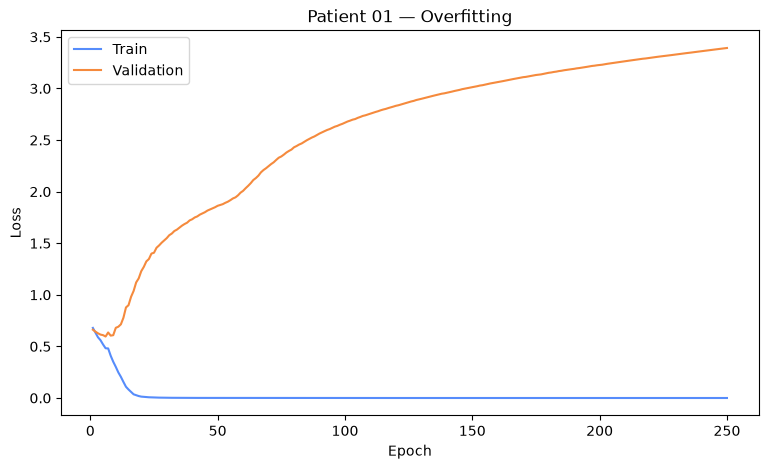

In [23]:
plt.figure(figsize=(9, 5))

plt.plot(
    overfit_df["epoch"],
    overfit_df["train_loss"],
    label="Train"
)

plt.plot(
    overfit_df["epoch"],
    overfit_df["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Patient 01 — Overfitting"
)

plt.legend()

plt.show()

In [24]:
best_epoch_idx = (
    overfit_df["val_loss"]
    .idxmin()
)

best_epoch = overfit_df.loc[
    best_epoch_idx
]

best_epoch

epoch            6.000000
train_loss       0.481969
val_loss         0.595898
gradient_norm    0.563499
val_pr_auc       0.629987
val_roc_auc      0.732689
Name: 5, dtype: float64

In [25]:
print(
    "Best epoch:",
    int(best_epoch["epoch"])
)

print(
    "Best validation loss:",
    best_epoch["val_loss"]
)

Best epoch: 6
Best validation loss: 0.5958982706069946


In [26]:
final_epoch = overfit_df.iloc[-1]

print(
    "Best validation loss:",
    best_epoch["val_loss"]
)

print(
    "Final validation loss:",
    final_epoch["val_loss"]
)

print(
    "Final training loss:",
    final_epoch["train_loss"]
)

Best validation loss: 0.5958982706069946
Final validation loss: 3.392249822616577
Final training loss: 1.8801800507617372e-06


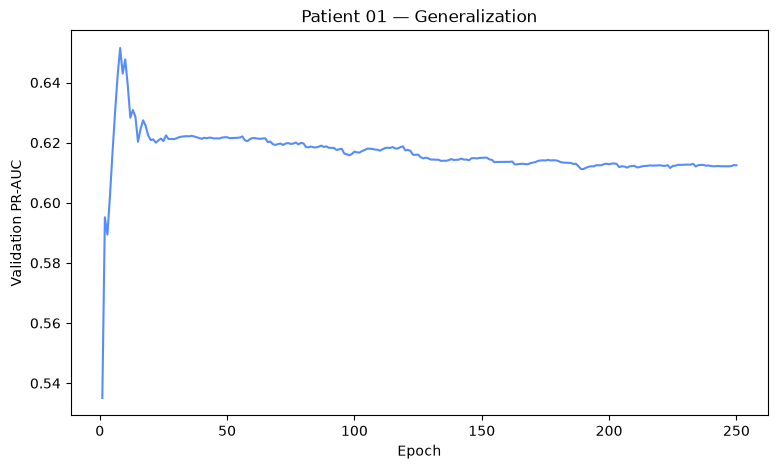

In [27]:
plt.figure(figsize=(9, 5))

plt.plot(
    overfit_df["epoch"],
    overfit_df["val_pr_auc"]
)

plt.xlabel("Epoch")
plt.ylabel("Validation PR-AUC")

plt.title(
    "Patient 01 — Generalization"
)

plt.show()

In [28]:
overfit_df.to_csv(
    "../outputs/metrics/patient01_overfit.csv",
    index=False
)

In [29]:
torch.save(
    overfit_model.state_dict(),
    "../outputs/models/patient01_overfit.pt"
)

## Patient 01 — Overfitting

### Síntomas
- Training loss continúa disminuyendo.
- Validation loss alcanza un mínimo y luego aumenta.
- Validation PR-AUC deja de mejorar o empeora.

### Hipótesis
El modelo tiene demasiada capacidad respecto al volumen de datos
y empieza a memorizar particularidades del training set.

### Causas inducidas
- Solo 300 observaciones de training.
- Red mucho más grande.
- Sin Dropout.
- Sin weight decay.
- 250 epochs.

### Diagnóstico
Overfitting.

### Posibles tratamientos
- Más datos.
- Menor capacidad.
- Dropout.
- Weight decay.
- Early stopping.

In [30]:
import copy

In [31]:
early_model = OverfitNet(
    X_train.shape[1]
)

In [32]:
early_optimizer = torch.optim.Adam(
    early_model.parameters(),
    lr=1e-3
)

In [33]:
patience = 15

best_val_loss = float("inf")
best_state = None

epochs_without_improvement = 0

early_history = []

In [34]:
for epoch in range(250):

    # =========================
    # TRAIN
    # =========================

    early_model.train()

    train_losses = []
    gradient_norms = []

    for xb, yb in train_small_loader:

        early_optimizer.zero_grad()

        logits = early_model(xb)

        loss = loss_fn(
            logits,
            yb
        )

        loss.backward()

        grad_norm = gradient_norm(
            early_model
        )

        early_optimizer.step()

        train_losses.append(
            loss.item()
        )

        gradient_norms.append(
            grad_norm
        )

    # =========================
    # VALIDATION
    # =========================

    early_model.eval()

    with torch.no_grad():

        val_logits = early_model(
            X_val_tensor
        )

        val_loss = loss_fn(
            val_logits,
            y_val_tensor
        )

        val_prob = torch.sigmoid(
            val_logits
        ).numpy()

    val_pr_auc = average_precision_score(
        y_val,
        val_prob
    )

    val_roc_auc = roc_auc_score(
        y_val,
        val_prob
    )

    # =========================
    # LOG
    # =========================

    early_history.append({
        "epoch": epoch + 1,
        "train_loss": np.mean(train_losses),
        "val_loss": val_loss.item(),
        "gradient_norm": np.mean(gradient_norms),
        "val_pr_auc": val_pr_auc,
        "val_roc_auc": val_roc_auc
    })

    # =========================
    # EARLY STOPPING
    # =========================

    if val_loss.item() < best_val_loss:

        best_val_loss = val_loss.item()

        best_state = copy.deepcopy(
            early_model.state_dict()
        )

        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:

        print(
            f"Early stopping at epoch {epoch + 1}"
        )

        break

Early stopping at epoch 20


In [35]:
early_model.load_state_dict(
    best_state
)

<All keys matched successfully>

In [36]:
early_df = pd.DataFrame(
    early_history
)

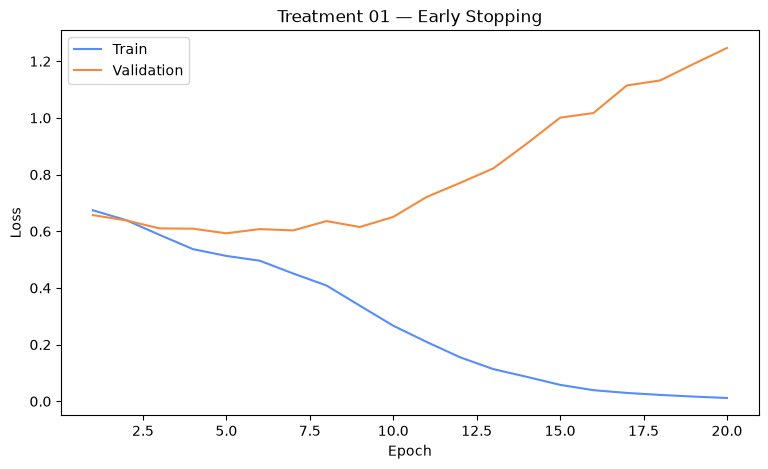

In [37]:
plt.figure(figsize=(9, 5))

plt.plot(
    early_df["epoch"],
    early_df["train_loss"],
    label="Train"
)

plt.plot(
    early_df["epoch"],
    early_df["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Treatment 01 — Early Stopping"
)

plt.legend()
plt.show()

In [38]:
wd_model = OverfitNet(
    X_train.shape[1]
)

wd_optimizer = torch.optim.AdamW(
    wd_model.parameters(),
    lr=1e-3,
    weight_decay=1e-3
)

wd_history = []

epochs = 250

for epoch in range(epochs):

    # =========================
    # TRAIN
    # =========================

    wd_model.train()

    train_losses = []
    gradient_norms = []

    for xb, yb in train_small_loader:

        wd_optimizer.zero_grad()

        logits = wd_model(xb)

        loss = loss_fn(
            logits,
            yb
        )

        loss.backward()

        grad_norm = gradient_norm(
            wd_model
        )

        wd_optimizer.step()

        train_losses.append(
            loss.item()
        )

        gradient_norms.append(
            grad_norm
        )

    # =========================
    # VALIDATION
    # =========================

    wd_model.eval()

    with torch.no_grad():

        val_logits = wd_model(
            X_val_tensor
        )

        val_loss = loss_fn(
            val_logits,
            y_val_tensor
        )

        val_prob = torch.sigmoid(
            val_logits
        ).numpy()

    val_pr_auc = average_precision_score(
        y_val,
        val_prob
    )

    val_roc_auc = roc_auc_score(
        y_val,
        val_prob
    )

    # =========================
    # LOG
    # =========================

    wd_history.append({

        "epoch": epoch + 1,

        "train_loss":
            np.mean(train_losses),

        "val_loss":
            val_loss.item(),

        "gradient_norm":
            np.mean(gradient_norms),

        "val_pr_auc":
            val_pr_auc,

        "val_roc_auc":
            val_roc_auc
    })

In [39]:
wd_df = pd.DataFrame(
    wd_history
)

In [40]:
class RegularizedNet(nn.Module):

    def __init__(self, n_features):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(n_features, 256),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(64, 1)
        )

    def forward(self, x):

        return self.network(x).squeeze(1)

In [41]:
drop_model = RegularizedNet(
    X_train.shape[1]
)

drop_optimizer = torch.optim.Adam(
    drop_model.parameters(),
    lr=1e-3
)

drop_history = []

epochs = 250

for epoch in range(epochs):

    # =========================
    # TRAIN
    # =========================

    drop_model.train()

    train_losses = []
    gradient_norms = []

    for xb, yb in train_small_loader:

        drop_optimizer.zero_grad()

        logits = drop_model(xb)

        loss = loss_fn(
            logits,
            yb
        )

        loss.backward()

        grad_norm = gradient_norm(
            drop_model
        )

        drop_optimizer.step()

        train_losses.append(
            loss.item()
        )

        gradient_norms.append(
            grad_norm
        )

    # =========================
    # VALIDATION
    # =========================

    drop_model.eval()

    with torch.no_grad():

        val_logits = drop_model(
            X_val_tensor
        )

        val_loss = loss_fn(
            val_logits,
            y_val_tensor
        )

        val_prob = torch.sigmoid(
            val_logits
        ).numpy()

    val_pr_auc = average_precision_score(
        y_val,
        val_prob
    )

    val_roc_auc = roc_auc_score(
        y_val,
        val_prob
    )

    # =========================
    # LOG
    # =========================

    drop_history.append({
        "epoch": epoch + 1,
        "train_loss": np.mean(train_losses),
        "val_loss": val_loss.item(),
        "gradient_norm": np.mean(gradient_norms),
        "val_pr_auc": val_pr_auc,
        "val_roc_auc": val_roc_auc
    })

In [42]:
drop_df = pd.DataFrame(
    drop_history
)

drop_df.head()

,epoch,train_loss,val_loss,gradient_norm,val_pr_auc,val_roc_auc
0,1,0.673464,0.662182,0.275052,0.594450,0.682823
1,2,0.634881,0.651181,0.313483,0.618263,0.708865
2,3,0.625716,0.638568,0.360093,0.635946,0.725531
3,4,0.597769,0.616171,0.426059,0.635807,0.734308
4,5,0.564513,0.595064,0.472274,0.626877,0.734914


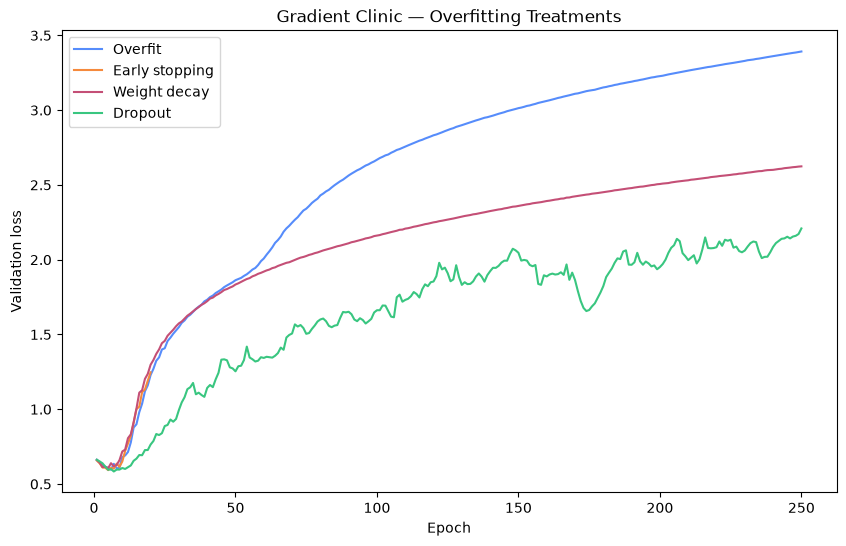

In [43]:
plt.figure(figsize=(10, 6))

plt.plot(
    overfit_df["epoch"],
    overfit_df["val_loss"],
    label="Overfit"
)

plt.plot(
    early_df["epoch"],
    early_df["val_loss"],
    label="Early stopping"
)

plt.plot(
    wd_df["epoch"],
    wd_df["val_loss"],
    label="Weight decay"
)

plt.plot(
    drop_df["epoch"],
    drop_df["val_loss"],
    label="Dropout"
)

plt.xlabel("Epoch")
plt.ylabel("Validation loss")

plt.title(
    "Gradient Clinic — Overfitting Treatments"
)

plt.legend()
plt.show()

In [45]:
comparison = pd.DataFrame({
    "model": [
        "Overfit",
        "Early stopping",
        "Weight decay",
        "Dropout"
    ],

    "best_val_loss": [
        overfit_df["val_loss"].min(),
        early_df["val_loss"].min(),
        wd_df["val_loss"].min(),
        drop_df["val_loss"].min()
    ],

    "best_val_pr_auc": [
        overfit_df["val_pr_auc"].max(),
        early_df["val_pr_auc"].max(),
        wd_df["val_pr_auc"].max(),
        drop_df["val_pr_auc"].max()
    ],

    "best_epoch": [
        int(overfit_df.loc[overfit_df["val_loss"].idxmin(), "epoch"]),
        int(early_df.loc[early_df["val_loss"].idxmin(), "epoch"]),
        int(wd_df.loc[wd_df["val_loss"].idxmin(), "epoch"]),
        int(drop_df.loc[drop_df["val_loss"].idxmin(), "epoch"])
    ]
})

comparison

,model,best_val_loss,best_val_pr_auc,best_epoch
0,Overfit,0.595898,0.651490,6
1,Early stopping,0.592804,0.649568,5
2,Weight decay,0.605363,0.634181,5
3,Dropout,0.583731,0.657816,7


In [46]:
comparison.to_csv(
    "../outputs/metrics/patient01_treatments.csv",
    index=False
)